C:\Users\TSingSV\AppData\Local\Temp\ipykernel_8776\2925545445.py:202: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


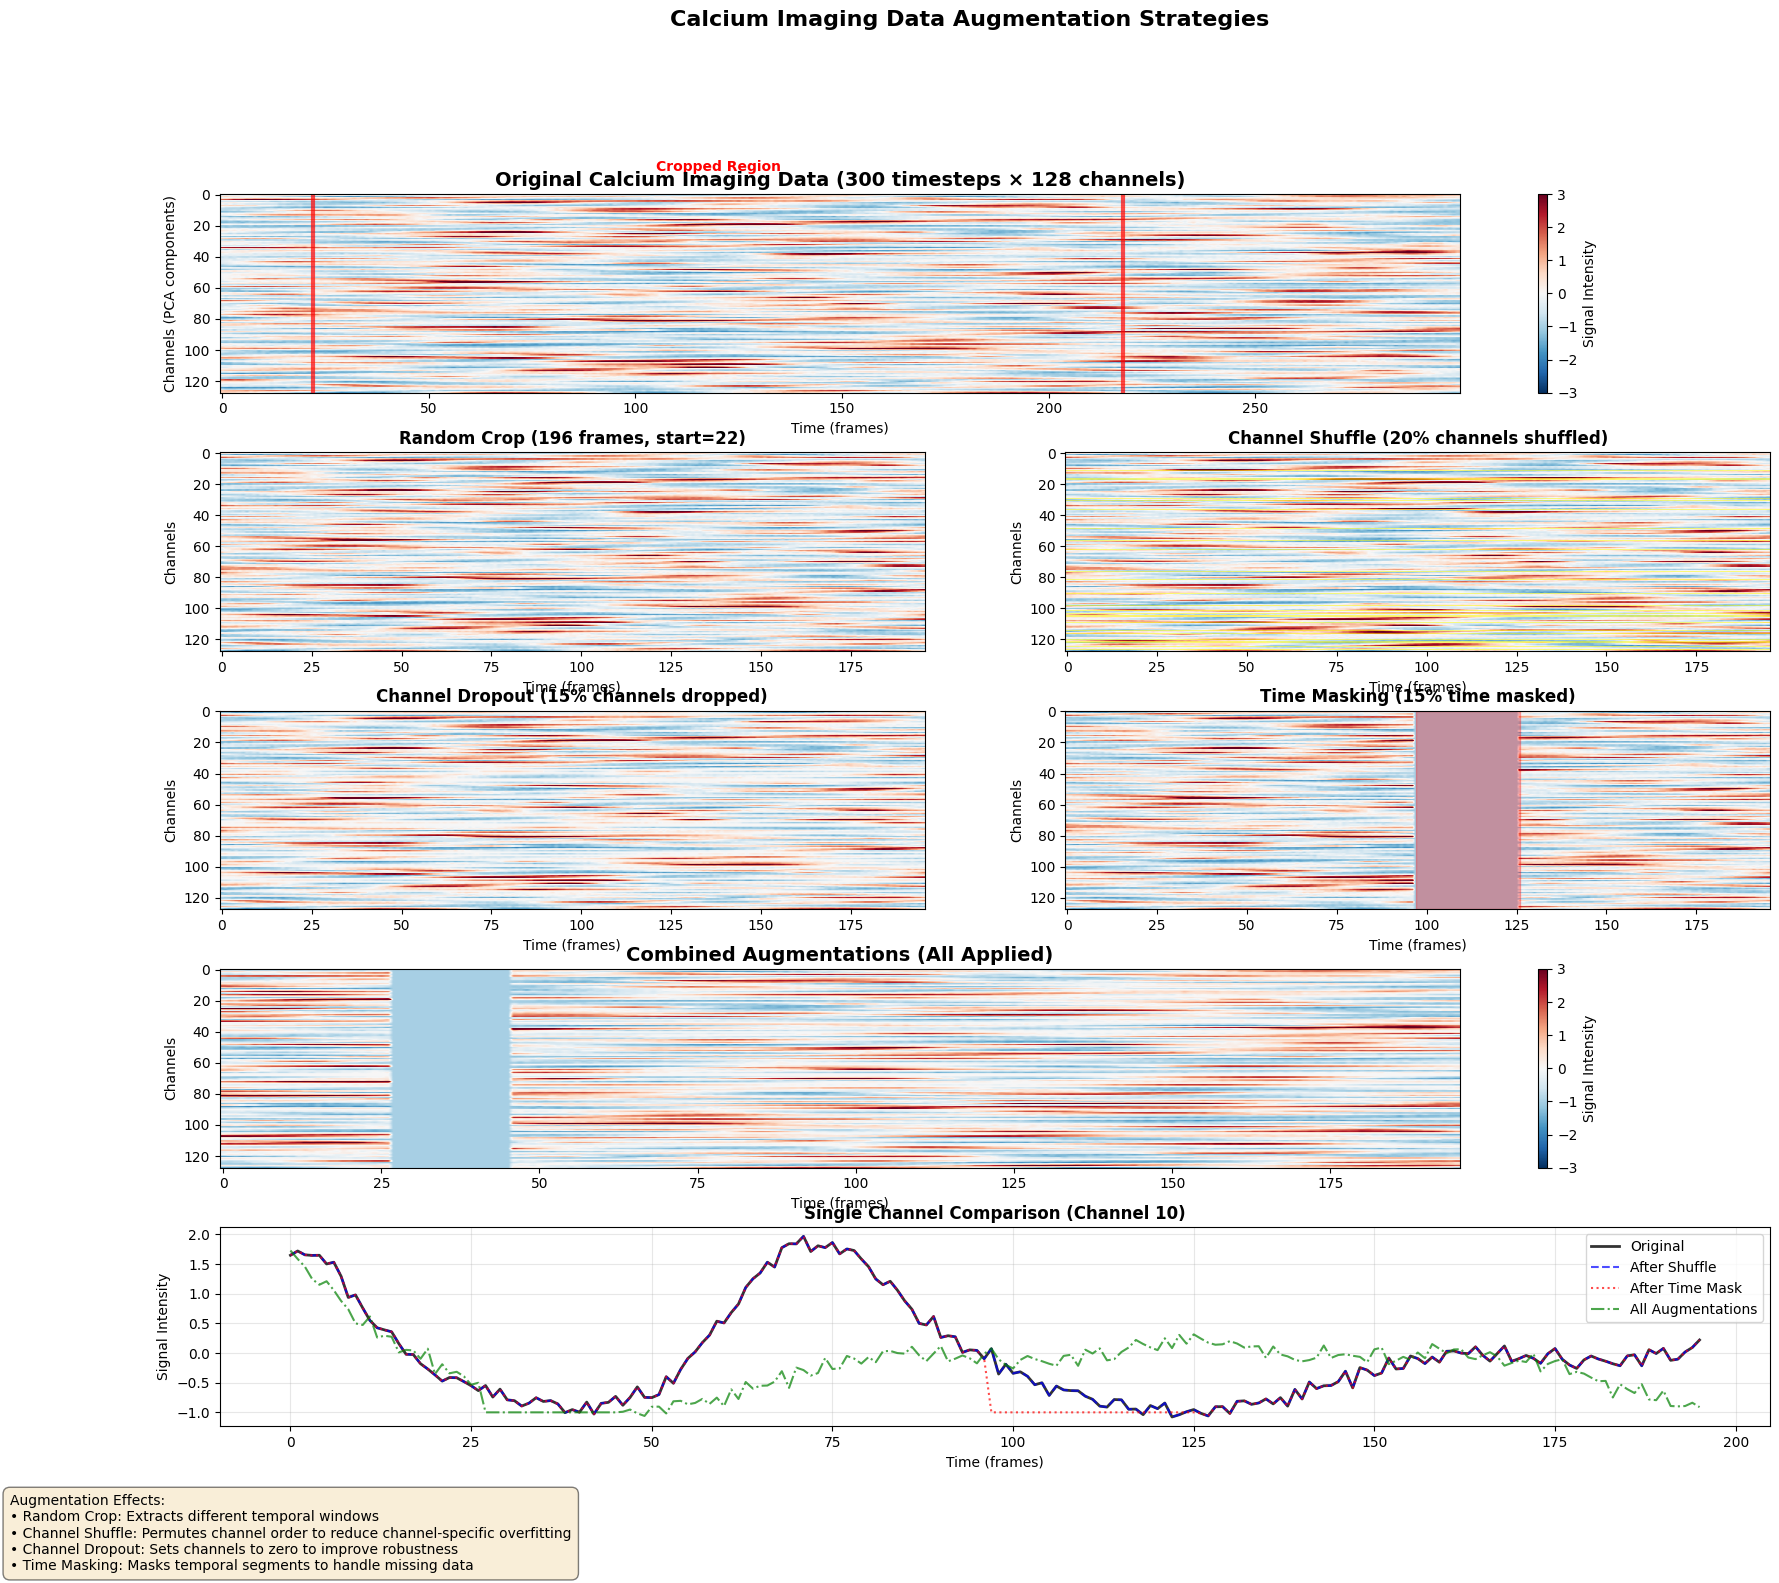

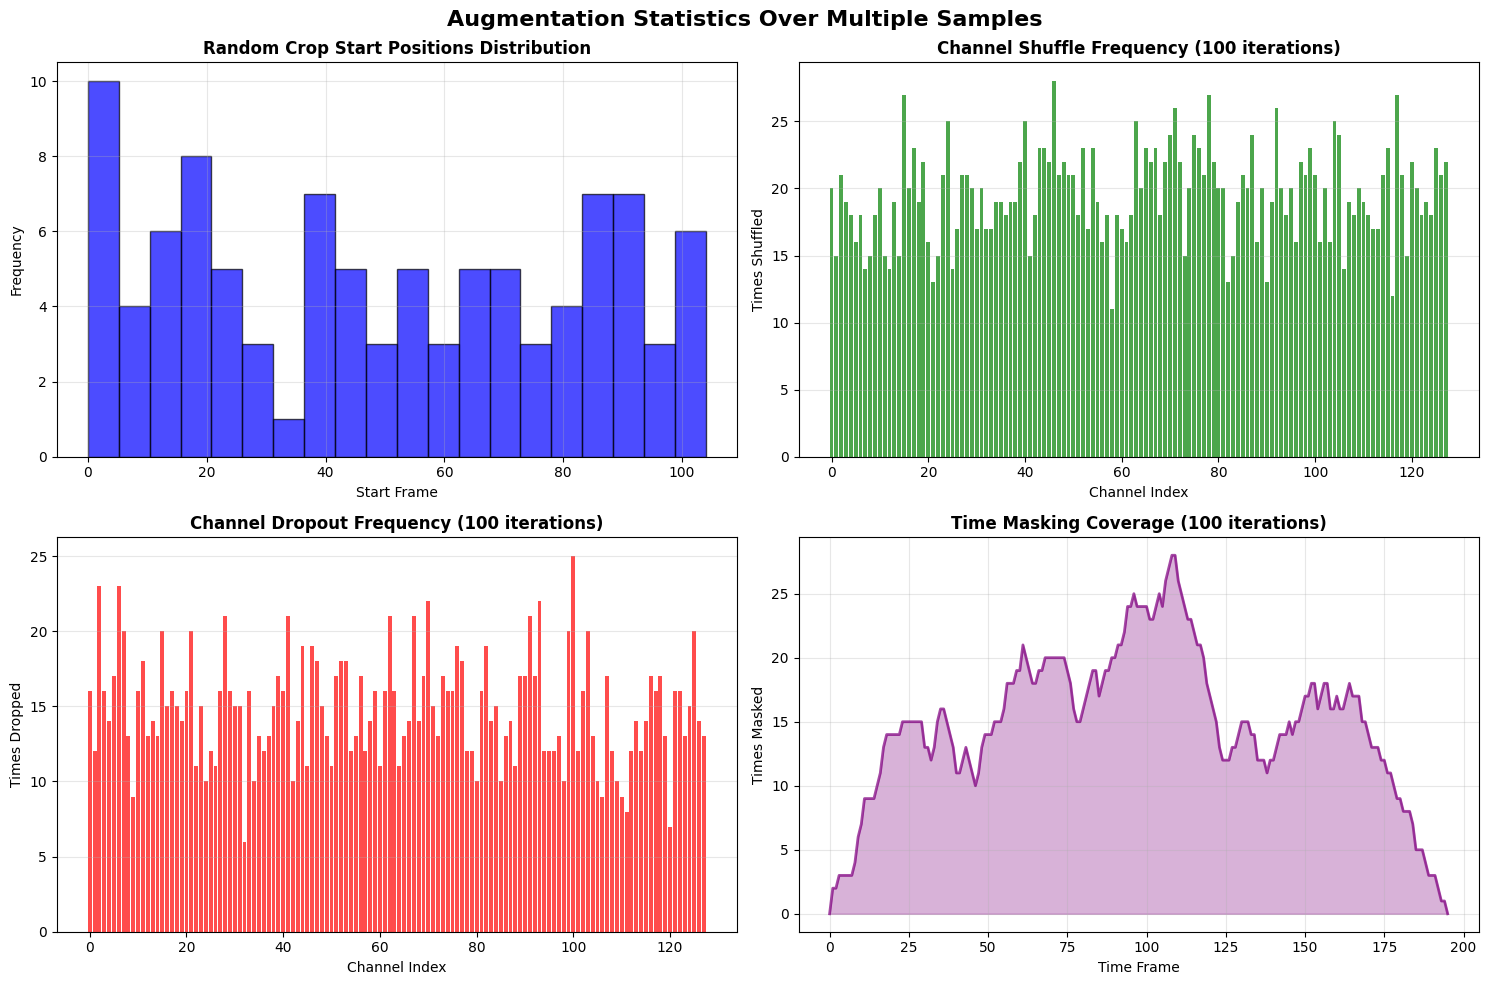

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from matplotlib.gridspec import GridSpec
import random


def generate_synthetic_calcium_data(n_channels=128, n_timesteps=300):
    """Generate synthetic calcium imaging data with realistic patterns"""
    # Base signals with different frequencies
    time = np.linspace(0, 10, n_timesteps)
    data = np.zeros((n_timesteps, n_channels))

    for i in range(n_channels):
        # Mix of oscillatory patterns and transients
        freq = np.random.uniform(0.5, 3)
        phase = np.random.uniform(0, 2 * np.pi)
        amplitude = np.random.uniform(0.5, 1.5)

        # Base oscillation
        base_signal = amplitude * np.sin(freq * time + phase)

        # Add random transients (calcium spikes)
        n_spikes = np.random.randint(2, 8)
        for _ in range(n_spikes):
            spike_time = np.random.randint(0, n_timesteps)
            spike_width = np.random.randint(5, 15)
            spike_amp = np.random.uniform(1, 3)

            spike_profile = np.exp(-0.5 * ((np.arange(n_timesteps) - spike_time) / spike_width) ** 2)
            base_signal += spike_amp * spike_profile

        # Add noise
        noise = np.random.normal(0, 0.1, n_timesteps)
        data[:, i] = base_signal + noise

    # Normalize
    data = (data - data.mean()) / data.std()
    return data


def apply_random_crop(data, seq_length=196):
    """Apply random cropping augmentation"""
    original_length = data.shape[0]
    if original_length > seq_length:
        start_idx = np.random.randint(0, original_length - seq_length + 1)
        cropped_data = data[start_idx:start_idx + seq_length].copy()
        return cropped_data, start_idx
    return data.copy(), 0


def apply_channel_shuffle(data, shuffle_prob=1.0, shuffle_ratio=0.2):
    """Apply channel shuffle augmentation"""
    augmented = data.copy()
    if random.random() < shuffle_prob:
        n_channels = int(shuffle_ratio * data.shape[1])
        if n_channels > 0:
            shuffle_idx = np.random.choice(data.shape[1], n_channels, replace=False)
            shuffled_order = np.random.permutation(n_channels)
            augmented[:, shuffle_idx] = augmented[:, shuffle_idx[shuffled_order]]
            return augmented, shuffle_idx
    return augmented, []


def apply_channel_dropout(data, dropout_prob=1.0, dropout_ratio=0.2):
    """Apply channel dropout augmentation"""
    augmented = data.copy()
    if random.random() < dropout_prob:
        n_dropout = int(dropout_ratio * data.shape[1])
        if n_dropout > 0:
            dropout_idx = np.random.choice(data.shape[1], n_dropout, replace=False)
            augmented[:, dropout_idx] = 0
            return augmented, dropout_idx
    return augmented, []


def apply_time_masking(data, mask_prob=1.0, mask_ratio=0.15):
    """Apply time masking augmentation"""
    augmented = data.copy()
    if random.random() < mask_prob:
        mask_length = int(mask_ratio * data.shape[0])
        if mask_length > 0 and data.shape[0] > mask_length:
            mask_start = np.random.randint(0, data.shape[0] - mask_length)
            augmented[mask_start:mask_start + mask_length] = -1
            return augmented, (mask_start, mask_length)
    return augmented, None


def plot_augmentation_comparison():
    """Create comprehensive visualization of all augmentation strategies"""
    # Generate synthetic data
    np.random.seed(42)
    random.seed(42)

    original_data = generate_synthetic_calcium_data(n_channels=128, n_timesteps=300)

    # Create figure with subplots
    fig = plt.figure(figsize=(20, 16))
    gs = GridSpec(5, 2, figure=fig, hspace=0.3, wspace=0.2)

    # Color settings
    cmap = 'RdBu_r'
    vmin, vmax = -3, 3

    # 1. Original Data
    ax1 = fig.add_subplot(gs[0, :])
    im1 = ax1.imshow(original_data.T, aspect='auto', cmap=cmap, vmin=vmin, vmax=vmax)
    ax1.set_title('Original Calcium Imaging Data (300 timesteps × 128 channels)', fontsize=14, fontweight='bold')
    ax1.set_xlabel('Time (frames)')
    ax1.set_ylabel('Channels (PCA components)')
    plt.colorbar(im1, ax=ax1, label='Signal Intensity')

    # 2. Random Crop
    ax2 = fig.add_subplot(gs[1, 0])
    cropped_data, crop_start = apply_random_crop(original_data, seq_length=196)
    im2 = ax2.imshow(cropped_data.T, aspect='auto', cmap=cmap, vmin=vmin, vmax=vmax)
    ax2.set_title(f'Random Crop (196 frames, start={crop_start})', fontsize=12, fontweight='bold')
    ax2.set_xlabel('Time (frames)')
    ax2.set_ylabel('Channels')

    # Add crop window indicator on original
    rect = patches.Rectangle((crop_start, -5), 196, 138, linewidth=3,
                             edgecolor='red', facecolor='none', alpha=0.7)
    ax1.add_patch(rect)
    ax1.text(crop_start + 98, -15, 'Cropped Region', ha='center',
             fontsize=10, color='red', fontweight='bold')

    # 3. Channel Shuffle
    ax3 = fig.add_subplot(gs[1, 1])
    shuffled_data, shuffle_idx = apply_channel_shuffle(cropped_data, shuffle_prob=1.0, shuffle_ratio=0.2)
    im3 = ax3.imshow(shuffled_data.T, aspect='auto', cmap=cmap, vmin=vmin, vmax=vmax)
    ax3.set_title(f'Channel Shuffle (20% channels shuffled)', fontsize=12, fontweight='bold')
    ax3.set_xlabel('Time (frames)')
    ax3.set_ylabel('Channels')

    # Highlight shuffled channels
    for idx in shuffle_idx:
        ax3.axhline(y=idx, color='yellow', linewidth=0.5, alpha=0.7)

    # 4. Channel Dropout
    ax4 = fig.add_subplot(gs[2, 0])
    dropout_data, dropout_idx = apply_channel_dropout(cropped_data, dropout_prob=1.0, dropout_ratio=0.15)
    im4 = ax4.imshow(dropout_data.T, aspect='auto', cmap=cmap, vmin=vmin, vmax=vmax)
    ax4.set_title(f'Channel Dropout (15% channels dropped)', fontsize=12, fontweight='bold')
    ax4.set_xlabel('Time (frames)')
    ax4.set_ylabel('Channels')

    # 5. Time Masking
    ax5 = fig.add_subplot(gs[2, 1])
    masked_data, mask_info = apply_time_masking(cropped_data, mask_prob=1.0, mask_ratio=0.15)
    im5 = ax5.imshow(masked_data.T, aspect='auto', cmap=cmap, vmin=vmin, vmax=vmax)
    ax5.set_title(f'Time Masking (15% time masked)', fontsize=12, fontweight='bold')
    ax5.set_xlabel('Time (frames)')
    ax5.set_ylabel('Channels')

    if mask_info:
        mask_start, mask_length = mask_info
        ax5.axvspan(mask_start, mask_start + mask_length, alpha=0.3, color='red')

    # 6. Combined Augmentations
    ax6 = fig.add_subplot(gs[3, :])
    # Apply all augmentations sequentially
    combined_data = original_data.copy()
    combined_data, _ = apply_random_crop(combined_data, seq_length=196)
    combined_data, _ = apply_channel_shuffle(combined_data, shuffle_prob=1.0, shuffle_ratio=0.1)
    combined_data, _ = apply_channel_dropout(combined_data, dropout_prob=1.0, dropout_ratio=0.1)
    combined_data, _ = apply_time_masking(combined_data, mask_prob=1.0, mask_ratio=0.1)

    im6 = ax6.imshow(combined_data.T, aspect='auto', cmap=cmap, vmin=vmin, vmax=vmax)
    ax6.set_title('Combined Augmentations (All Applied)', fontsize=14, fontweight='bold')
    ax6.set_xlabel('Time (frames)')
    ax6.set_ylabel('Channels')
    plt.colorbar(im6, ax=ax6, label='Signal Intensity')

    # 7. Signal Comparison (single channel)
    ax7 = fig.add_subplot(gs[4, :])
    channel_idx = 10
    time_axis = np.arange(196)

    ax7.plot(time_axis, cropped_data[:, channel_idx], 'k-', linewidth=2, label='Original', alpha=0.8)
    ax7.plot(time_axis, shuffled_data[:, channel_idx], 'b--', linewidth=1.5, label='After Shuffle', alpha=0.7)
    ax7.plot(time_axis, masked_data[:, channel_idx], 'r:', linewidth=1.5, label='After Time Mask', alpha=0.7)
    ax7.plot(time_axis, combined_data[:, channel_idx], 'g-.', linewidth=1.5, label='All Augmentations', alpha=0.7)

    ax7.set_title(f'Single Channel Comparison (Channel {channel_idx})', fontsize=12, fontweight='bold')
    ax7.set_xlabel('Time (frames)')
    ax7.set_ylabel('Signal Intensity')
    ax7.legend(loc='upper right')
    ax7.grid(True, alpha=0.3)

    plt.suptitle('Calcium Imaging Data Augmentation Strategies', fontsize=16, fontweight='bold', y=0.995)

    # Add text annotations
    fig.text(0.02, 0.02,
             'Augmentation Effects:\n'
             '• Random Crop: Extracts different temporal windows\n'
             '• Channel Shuffle: Permutes channel order to reduce channel-specific overfitting\n'
             '• Channel Dropout: Sets channels to zero to improve robustness\n'
             '• Time Masking: Masks temporal segments to handle missing data',
             fontsize=10, bbox=dict(boxstyle="round,pad=0.5", facecolor="wheat", alpha=0.5))

    plt.tight_layout()
    return fig


def plot_augmentation_statistics():
    """Plot statistics showing the effect of augmentations over multiple samples"""
    fig, axes = plt.subplots(2, 2, figsize=(15, 10))

    np.random.seed(42)
    n_samples = 100

    # Generate base data
    base_data = generate_synthetic_calcium_data(n_channels=128, n_timesteps=300)

    # 1. Random Crop Distribution
    ax = axes[0, 0]
    crop_starts = []
    for _ in range(n_samples):
        _, start = apply_random_crop(base_data, seq_length=196)
        crop_starts.append(start)

    ax.hist(crop_starts, bins=20, alpha=0.7, color='blue', edgecolor='black')
    ax.set_title('Random Crop Start Positions Distribution', fontweight='bold')
    ax.set_xlabel('Start Frame')
    ax.set_ylabel('Frequency')
    ax.grid(True, alpha=0.3)

    # 2. Channel Shuffle Pattern
    ax = axes[0, 1]
    channel_shuffle_counts = np.zeros(128)
    for _ in range(n_samples):
        _, shuffle_idx = apply_channel_shuffle(base_data[:196], shuffle_prob=1.0, shuffle_ratio=0.2)
        channel_shuffle_counts[list(shuffle_idx)] += 1

    ax.bar(range(128), channel_shuffle_counts, alpha=0.7, color='green')
    ax.set_title('Channel Shuffle Frequency (100 iterations)', fontweight='bold')
    ax.set_xlabel('Channel Index')
    ax.set_ylabel('Times Shuffled')
    ax.grid(True, alpha=0.3, axis='y')

    # 3. Channel Dropout Pattern
    ax = axes[1, 0]
    channel_dropout_counts = np.zeros(128)
    for _ in range(n_samples):
        _, dropout_idx = apply_channel_dropout(base_data[:196], dropout_prob=1.0, dropout_ratio=0.15)
        channel_dropout_counts[list(dropout_idx)] += 1

    ax.bar(range(128), channel_dropout_counts, alpha=0.7, color='red')
    ax.set_title('Channel Dropout Frequency (100 iterations)', fontweight='bold')
    ax.set_xlabel('Channel Index')
    ax.set_ylabel('Times Dropped')
    ax.grid(True, alpha=0.3, axis='y')

    # 4. Time Mask Coverage
    ax = axes[1, 1]
    time_mask_coverage = np.zeros(196)
    for _ in range(n_samples):
        _, mask_info = apply_time_masking(base_data[:196], mask_prob=1.0, mask_ratio=0.15)
        if mask_info:
            start, length = mask_info
            time_mask_coverage[start:start + length] += 1

    ax.plot(time_mask_coverage, alpha=0.7, color='purple', linewidth=2)
    ax.fill_between(range(196), time_mask_coverage, alpha=0.3, color='purple')
    ax.set_title('Time Masking Coverage (100 iterations)', fontweight='bold')
    ax.set_xlabel('Time Frame')
    ax.set_ylabel('Times Masked')
    ax.grid(True, alpha=0.3)

    plt.suptitle('Augmentation Statistics Over Multiple Samples', fontsize=16, fontweight='bold')
    plt.tight_layout()
    return fig


# Create visualizations
fig1 = plot_augmentation_comparison()
plt.show()

fig2 = plot_augmentation_statistics()
plt.show()